# FINESST radiation site map

Edit the `sites` table in the next cell, then run all cells to make a western-US terrain map with state boundaries and labeled radiation sites.

In [3]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import requests
from rasterio.windows import from_bounds

plt.rcParams.update(
    {
        "font.size": 20,
        "font.weight": "bold",
        "axes.labelweight": "bold",
        "axes.titleweight": "bold",
        "axes.titlesize": 28,
        "axes.labelsize": 22,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 18,
        "figure.dpi": 150,
        "savefig.dpi": 300,
    }
)

# Western-US map bounds: (west, east, south, north). Adjust if you want a tighter figure.
MAP_BOUNDS = (-125.0, -101.5, 31.0, 49.5)

# Paste/edit your radiation sites here. Longitudes should be negative in the western US.
sites = pd.DataFrame(
    [
        {"name": "Gothic", "lat": 38.96, "lon": -106.99},
        {"name": "Atwater", "lat": 40.591, "lon": -111.638},
        {"name": "CUES", "lat": 37.643, "lon": -119.029},
        {"name": "Reynolds Creek", "lat": 37.908, "lon": -107.725},
    ]
)

OUTPUT_FIG = Path("figures/finesst_radiation_sites_western_us.png")


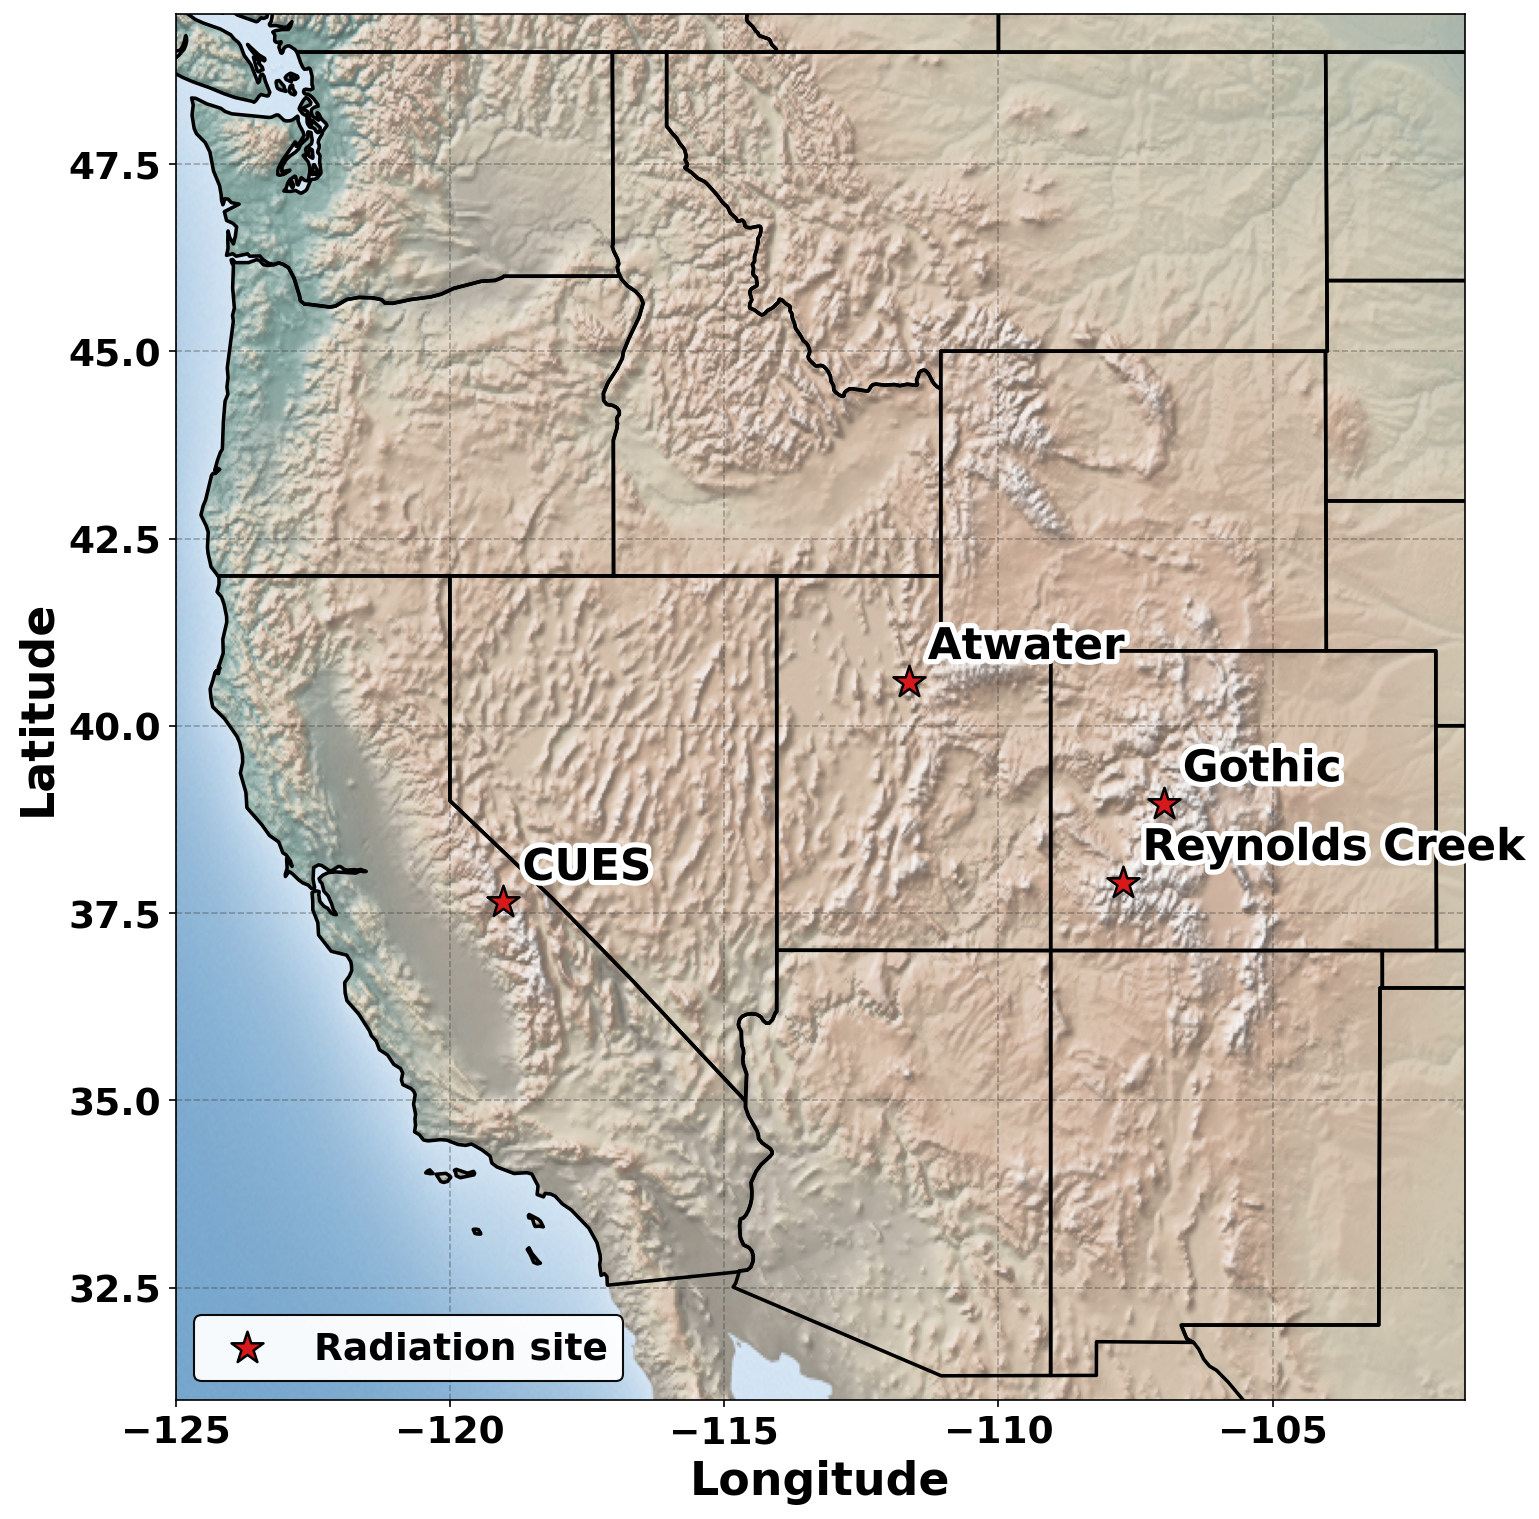

In [4]:
def download_natural_earth_relief(out_dir="analysis/data/natural_earth"):
    """Download Natural Earth shaded relief used as the terrain base map."""
    out_dir = Path(out_dir)
    tif_path = out_dir / "HYP_50M_SR_W.tif"
    if tif_path.exists():
        return tif_path

    out_dir.mkdir(parents=True, exist_ok=True)
    url = "https://naturalearth.s3.amazonaws.com/50m_raster/HYP_50M_SR_W.zip"
    zip_path = out_dir / "HYP_50M_SR_W.zip"
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    zip_path.write_bytes(response.content)

    import zipfile

    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(out_dir)
    return tif_path


def download_natural_earth_states(out_dir="analysis/data/natural_earth"):
    """Download Natural Earth admin-1 boundaries used for western-state outlines."""
    out_dir = Path(out_dir)
    shp_path = out_dir / "ne_50m_admin_1_states_provinces.shp"
    if shp_path.exists():
        return shp_path

    out_dir.mkdir(parents=True, exist_ok=True)
    url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
    zip_path = out_dir / "ne_50m_admin_1_states_provinces.zip"
    response = requests.get(url, timeout=120)
    response.raise_for_status()
    zip_path.write_bytes(response.content)

    import zipfile

    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(out_dir)
    return shp_path


def read_western_states(bounds):
    west, east, south, north = bounds
    states = gpd.read_file(download_natural_earth_states())
    states = states[states["admin"].isin(["United States of America", "Canada", "Mexico"])]
    return states.cx[west:east, south:north]


def read_relief_for_bounds(relief_path, bounds):
    west, east, south, north = bounds
    with rasterio.open(relief_path) as src:
        window = from_bounds(west, south, east, north, transform=src.transform)
        relief = src.read([1, 2, 3], window=window).astype(float)
        transform = src.window_transform(window)

    relief_rgb = np.moveaxis(relief, 0, -1) / 255.0

    relief_extent = (
        transform.c,
        transform.c + transform.a * relief_rgb.shape[1],
        transform.f + transform.e * relief_rgb.shape[0],
        transform.f,
    )
    return relief_rgb, relief_extent


def plot_site_map(sites, bounds=MAP_BOUNDS, output_fig=OUTPUT_FIG):
    west, east, south, north = bounds
    relief_path = download_natural_earth_relief()
    relief_rgb, relief_extent = read_relief_for_bounds(relief_path, bounds)

    states = read_western_states(bounds)

    fig, ax = plt.subplots(figsize=(14, 12))
    ax.set_facecolor("#c9e3ee")
    ax.imshow(relief_rgb, extent=relief_extent, origin="upper", zorder=0)
    states.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.7, zorder=4)

    ax.scatter(
        sites["lon"],
        sites["lat"],
        s=260,
        marker="*",
        color="#d7191c",
        edgecolor="black",
        linewidth=1.2,
        zorder=6,
        label="Radiation site",
    )

    ax.set_xlim(west, east)
    ax.set_ylim(south, north)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, linewidth=0.8, color="0.2", alpha=0.35, linestyle="--")
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")

    # ax.set_title("Western U.S. Radiation Observation Sites", pad=18)
    ax.legend(loc="lower left", frameon=True, facecolor="white", edgecolor="black", framealpha=0.95)

    output_fig = Path(output_fig)
    output_fig.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_fig, bbox_inches="tight")
    return fig, ax


fig, ax = plot_site_map(sites)
